# Multi-Touch Marketing Attribution & ROI Dashboard

## Exploratory Data Analysis (EDA)

**Author:** Sanket More

**Objective:**
- Load the raw dataset
- Explore its structure
- Identify data quality issues
- Prepare for cleaning and SQL modeling

In [2]:
# Import required libraries
import pandas as pd
import numpy as np

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv("../data/raw/multi_touch_attribution_data.csv")

# Display the first 5 rows
df.head()

,User ID,Timestamp,Channel,Campaign,Conversion
0,83281,2025-02-10 07:58:51,Email,New Product Launch,No
1,68071,2025-02-10 23:38:48,Search Ads,Winter Sale,No
2,90131,2025-02-11 10:41:07,Social Media,Brand Awareness,Yes
3,71026,2025-02-10 08:19:44,Direct Traffic,-,Yes
4,94486,2025-02-10 15:15:46,Email,Retargeting,Yes


In [4]:
# Dataset Shape
print("Number of Rows and Columns:")
print(df.shape)


Number of Rows and Columns:
(10000, 5)


In [5]:
# Column Names
print("Columns in Dataset:")
print(df.columns)

Columns in Dataset:
Index(['User ID', 'Timestamp', 'Channel', 'Campaign', 'Conversion'], dtype='str')


In [6]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   User ID     10000 non-null  int64
 1   Timestamp   10000 non-null  str  
 2   Channel     10000 non-null  str  
 3   Campaign    10000 non-null  str  
 4   Conversion  10000 non-null  str  
dtypes: int64(1), str(4)
memory usage: 390.8 KB


In [7]:
# Summary Statistics
df.describe(include='all')

,User ID,Timestamp,Channel,Campaign,Conversion
count,10000.00000,10000,10000,10000,10000
unique,NaN,9737,6,6,2
top,NaN,2025-02-11 09:45:49,Direct Traffic,-,No
freq,NaN,3,1721,3131,5056
mean,54957.01700,NaN,NaN,NaN,NaN
std,25685.14741,NaN,NaN,NaN,NaN
min,10028.00000,NaN,NaN,NaN,NaN
25%,32391.00000,NaN,NaN,NaN,NaN
50%,55446.00000,NaN,NaN,NaN,NaN
75%,77298.00000,NaN,NaN,NaN,NaN


In [8]:
# Missing Values
df.isnull().sum()

User ID       0
Timestamp     0
Channel       0
Campaign      0
Conversion    0
dtype: int64

In [9]:
# Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
# Display all unique marketing channels

unique_channels = df["Channel"].unique()

print("Unique Marketing Channels:")
print(unique_channels)

Unique Marketing Channels:
<StringArray>
[         'Email',     'Search Ads',   'Social Media', 'Direct Traffic',
       'Referral',    'Display Ads']
Length: 6, dtype: str


In [11]:
# Count the number of unique marketing channels

num_channels = df["Channel"].nunique()

print("Number of Unique Marketing Channels:", num_channels)

Number of Unique Marketing Channels: 6


In [12]:
# Display all unique marketing campaigns

unique_campaigns = df["Campaign"].unique()

print("Unique Marketing Campaigns:")
print(unique_campaigns)

Unique Marketing Campaigns:
<StringArray>
['New Product Launch',        'Winter Sale',    'Brand Awareness',
                  '-',        'Retargeting',     'Discount Offer']
Length: 6, dtype: str


In [13]:
# Count the number of unique marketing campaigns

num_campaigns = df["Campaign"].nunique()

print("Number of Unique Marketing Campaigns:", num_campaigns)


Number of Unique Marketing Campaigns: 6


In [14]:
# Display the distribution of conversions

conversion_distribution = df["Conversion"].value_counts()

print("Conversion Distribution:")
print(conversion_distribution)

Conversion Distribution:
Conversion
No     5056
Yes    4944
Name: count, dtype: int64


In [15]:
# Display the distribution of customer journeys across marketing channels

channel_distribution = df["Channel"].value_counts()

print("Marketing Channel Distribution:")
print(channel_distribution)

Marketing Channel Distribution:
Channel
Direct Traffic    1721
Referral          1685
Display Ads       1669
Social Media      1662
Email             1654
Search Ads        1609
Name: count, dtype: int64


### Business Insight

The marketing traffic is distributed fairly evenly across all six marketing channels, with Direct Traffic generating the highest number of customer journeys (1,721) and Search Ads generating the lowest (1,609). The small variation suggests that the company has adopted a balanced multi-channel marketing strategy rather than relying heavily on a single acquisition source.

While Direct Traffic contributes the highest traffic volume, further analysis is required to determine whether it also delivers the highest conversion rate and return on investment.

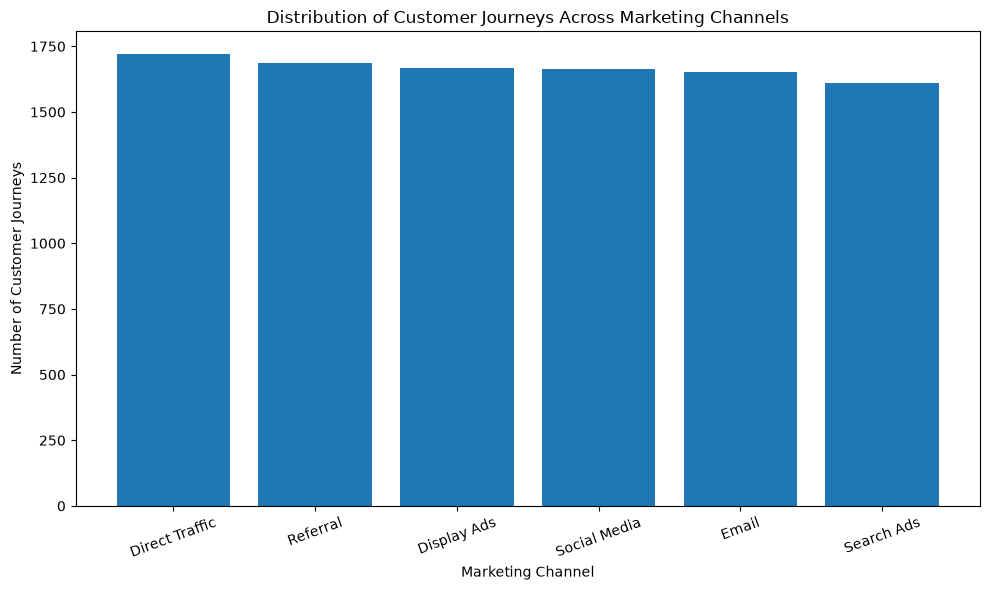

In [16]:
import matplotlib.pyplot as plt

# Create a bar chart for marketing channel distribution
channel_distribution = df["Channel"].value_counts()

plt.figure(figsize=(10,6))
plt.bar(channel_distribution.index, channel_distribution.values)

plt.title("Distribution of Customer Journeys Across Marketing Channels")
plt.xlabel("Marketing Channel")
plt.ylabel("Number of Customer Journeys")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Business Insight

The bar chart shows that customer journeys are distributed relatively evenly across all six marketing channels. Direct Traffic generated the highest number of customer journeys (1,721), while Search Ads generated the lowest (1,609).

The small variation between channels indicates that the company follows a balanced multi-channel acquisition strategy rather than depending heavily on a single marketing source. Further analysis is required to determine which channels generate the highest conversion rates and return on investment.

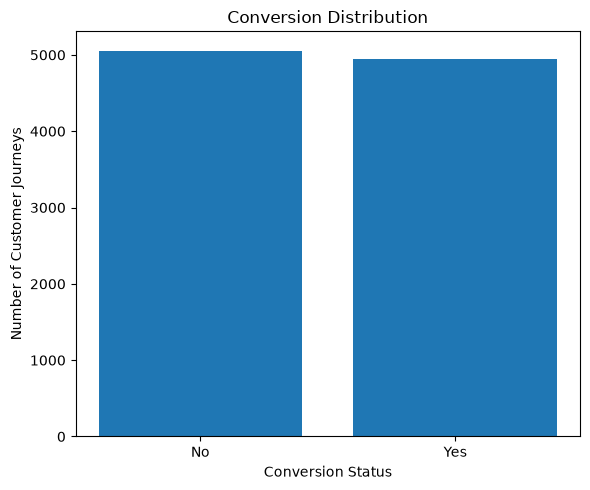

In [17]:
# Create a bar chart for conversion distribution

conversion_distribution = df["Conversion"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(conversion_distribution.index, conversion_distribution.values)

plt.title("Conversion Distribution")
plt.xlabel("Conversion Status")
plt.ylabel("Number of Customer Journeys")

plt.tight_layout()
plt.show()

In [18]:
# Calculate conversion counts by marketing channel

channel_conversion = pd.crosstab(df["Channel"], df["Conversion"])

print(channel_conversion)


Conversion       No  Yes
Channel                 
Direct Traffic  868  853
Display Ads     841  828
Email           824  830
Referral        844  841
Search Ads      837  772
Social Media    842  820


### Business Insight

Email is the only marketing channel where conversions slightly exceed non-conversions, indicating relatively stronger conversion performance. Search Ads recorded the lowest number of conversions compared to other channels despite generating a comparable number of customer journeys.

This suggests that while traffic acquisition across channels is balanced, conversion efficiency differs by channel. Search Ads may require optimization in targeting, keyword selection, ad creatives, or landing page experience to improve conversion performance.

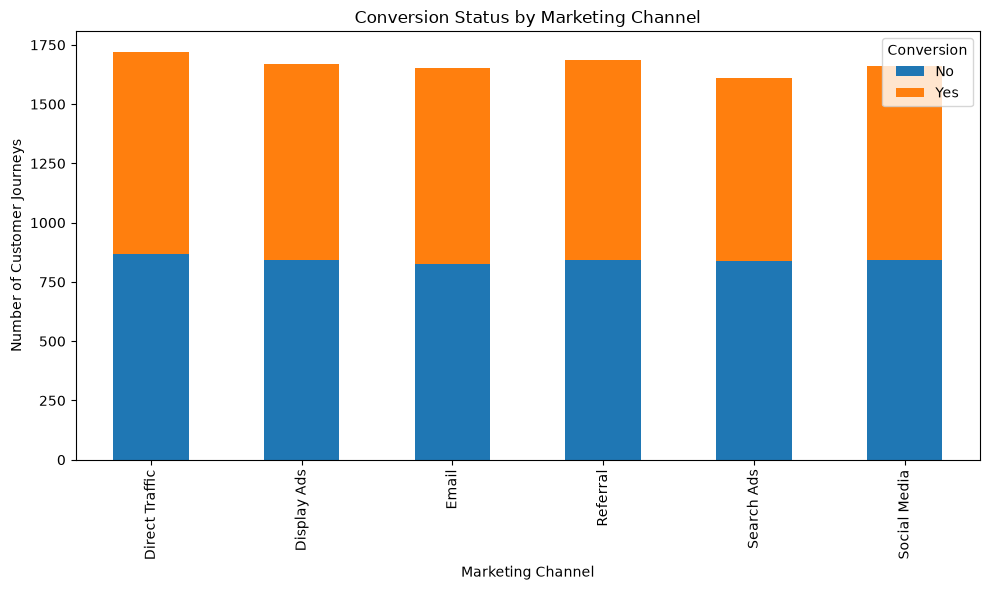

In [19]:
# Plot conversion status by marketing channel

channel_conversion.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Conversion Status by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Number of Customer Journeys")

plt.legend(title="Conversion")

plt.tight_layout()
plt.show()

### Business Insight

The stacked bar chart shows that customer journeys are distributed relatively evenly across all marketing channels. Email is the only channel where converted customers slightly exceed non-converted customers, indicating comparatively stronger conversion efficiency.

Search Ads generated the lowest number of conversions despite having a similar number of customer journeys as other channels, suggesting opportunities to improve campaign targeting, keyword strategy, ad creatives, or landing page optimization.

Overall, the organization appears to follow a balanced multi-channel marketing strategy, with performance differences arising from conversion effectiveness rather than traffic volume.